# pdfarabic — Usage Examples

This notebook demonstrates all features of the `pdfarabic` package for extracting
Arabic text from PDF files with proper RTL handling, ligature fixes, and table support.


## 1. Basic: Extract full PDF to text


In [1]:
from pdfarabic import extract_pdf

text = extract_pdf("download/الدستور-1706626006826.pdf")
# Print first 500 chars
print(text[:500])

الدستور

ظهير شريف رقم 1.11.91 صادر في 27 من شعبان 1432

(29 يوليو 2011) بتنفيذ نص الدستور 1

الحمد لله وحده،

الطابع الشريف- بداخله:

(محمد بن الحسن بن محمد بن يوسف الله وليه)

يعلم من ظهيرنا الشريف هذا، أسماه الله وأعز أمره أننا:

بعد الاطلاع على الدستور ولا سيما الفصلين 29 و 105 منه؛

وعلى الظهير الشريف رقم 1.11.82 الصادر في 14 من رجب 1432

(17 يونيو 2011) بعرض مشروع الدستور على الاستفتاء؛

وعلى القانون التنظيمي رقم 29.93 المتعلق بالمجلس الدستوري الصادر بتنفيذه

الظهير الشريف رقم 1.94.124 بتا


## 2. Page-level: Extract a single page


In [2]:
import fitz
from pdfarabic import extract_page

doc = fitz.open("download/الدستور-1706626006826.pdf")
page = doc[0]  # first page

text = extract_page(page)
print(text)

doc.close()

الدستور


## 3. Cropping: Remove headers/footers by pixels or percentage


In [3]:
# Crop 50 points from top, 30 from bottom (removes headers/page numbers)
text = extract_pdf(
    "download/الدستور-1706626006826.pdf",
    crop_top=50,
    crop_bottom=30,
)
print(text[:500])

الدستور

ظهير شريف رقم 1.11.91 صادر في 27 من شعبان 1432

(29 يوليو 2011) بتنفيذ نص الدستور 1

الحمد لله وحده،

الطابع الشريف- بداخله:

(محمد بن الحسن بن محمد بن يوسف الله وليه)

يعلم من ظهيرنا الشريف هذا، أسماه الله وأعز أمره أننا:

بعد الاطلاع على الدستور ولا سيما الفصلين 29 و 105 منه؛

وعلى الظهير الشريف رقم 1.11.82 الصادر في 14 من رجب 1432

(17 يونيو 2011) بعرض مشروع الدستور على الاستفتاء؛

وعلى القانون التنظيمي رقم 29.93 المتعلق بالمجلس الدستوري الصادر بتنفيذه

الظهير الشريف رقم 1.94.124 بتا


In [ ]:
# Crop by percentage: 5% from top, 3% from bottom
text = extract_pdf(
    "download/الدستور-1706626006826.pdf",
    crop_top=5,
    crop_bottom=3,
    crop_unit="pct",
)
print(text[:500])

## 4. Footer detection: Auto-remove footnotes below separator lines

Enabled by default. Detects `------` separator lines (both vector drawings and
text dashes) and removes everything below them. This catches footnotes like
"تم استدراك الخطأ بالجريدة الرسمية..." that appear below a horizontal rule.


In [4]:
# Footer detection is ON by default
text_with = extract_pdf(
    "download/ظهير شريف رقم 1.15.108 بتنفيذ القانون رقم 80.14 المتعلق بالمؤسسات السياحية-1775211211375.pdf",
    detect_footer=True,
)

# Disable it to keep footnotes
text_without = extract_pdf(
    "download/ظهير شريف رقم 1.15.108 بتنفيذ القانون رقم 80.14 المتعلق بالمؤسسات السياحية-1775211211375.pdf",
    detect_footer=False,
)

print(f"With footer detection:    {len(text_with):,} chars")
print(f"Without footer detection: {len(text_without):,} chars")
print(f"Footnote text removed:    {len(text_without) - len(text_with):,} chars")

With footer detection:    24,835 chars
Without footer detection: 25,847 chars
Footnote text removed:    1,012 chars


## 5. Tables: Automatic detection and pipe-delimited formatting

Tables are automatically detected, extracted with proper Arabic RTL ordering,
and formatted as pipe-delimited text. Merged cells are filled down so every
row is self-contained.


In [5]:
# This PDF has multiple tables (الجدول «أ», «ب», «ج»)
doc = fitz.open(
    "download/ظهير شريف رقم 1.11.172 بتنفيذ القانوستشارين-1733925566940.pdf"
)
page = doc[5]  # Page 6 has الجدول «أ»

text = extract_page(page)
print(text)

doc.close()

الجدول «أ»

الجهة |  | عدد المقاعد المخصصة لممثلي الجماعات الترابية
الجهة | المجلس الجهوي | المجالس الجماعية ومجالس العمالات والأقاليم
طنجة - تطوان - الحسيمة | 2 | 2
الشرق | 2 | 0
فاس - مكناس | 2 | 2
الرباط - سلا - القنيطرة | 2 | 2
بني ملال - خنيفرة | 2 | 0
الدار البيضاء - سطات | 2 | 7
مراكش - آسفي | 2 | 2
درعة - تافيلالت | 2 | 0

سوس -ماسة 2 0


## 6. Page-level control with cropping


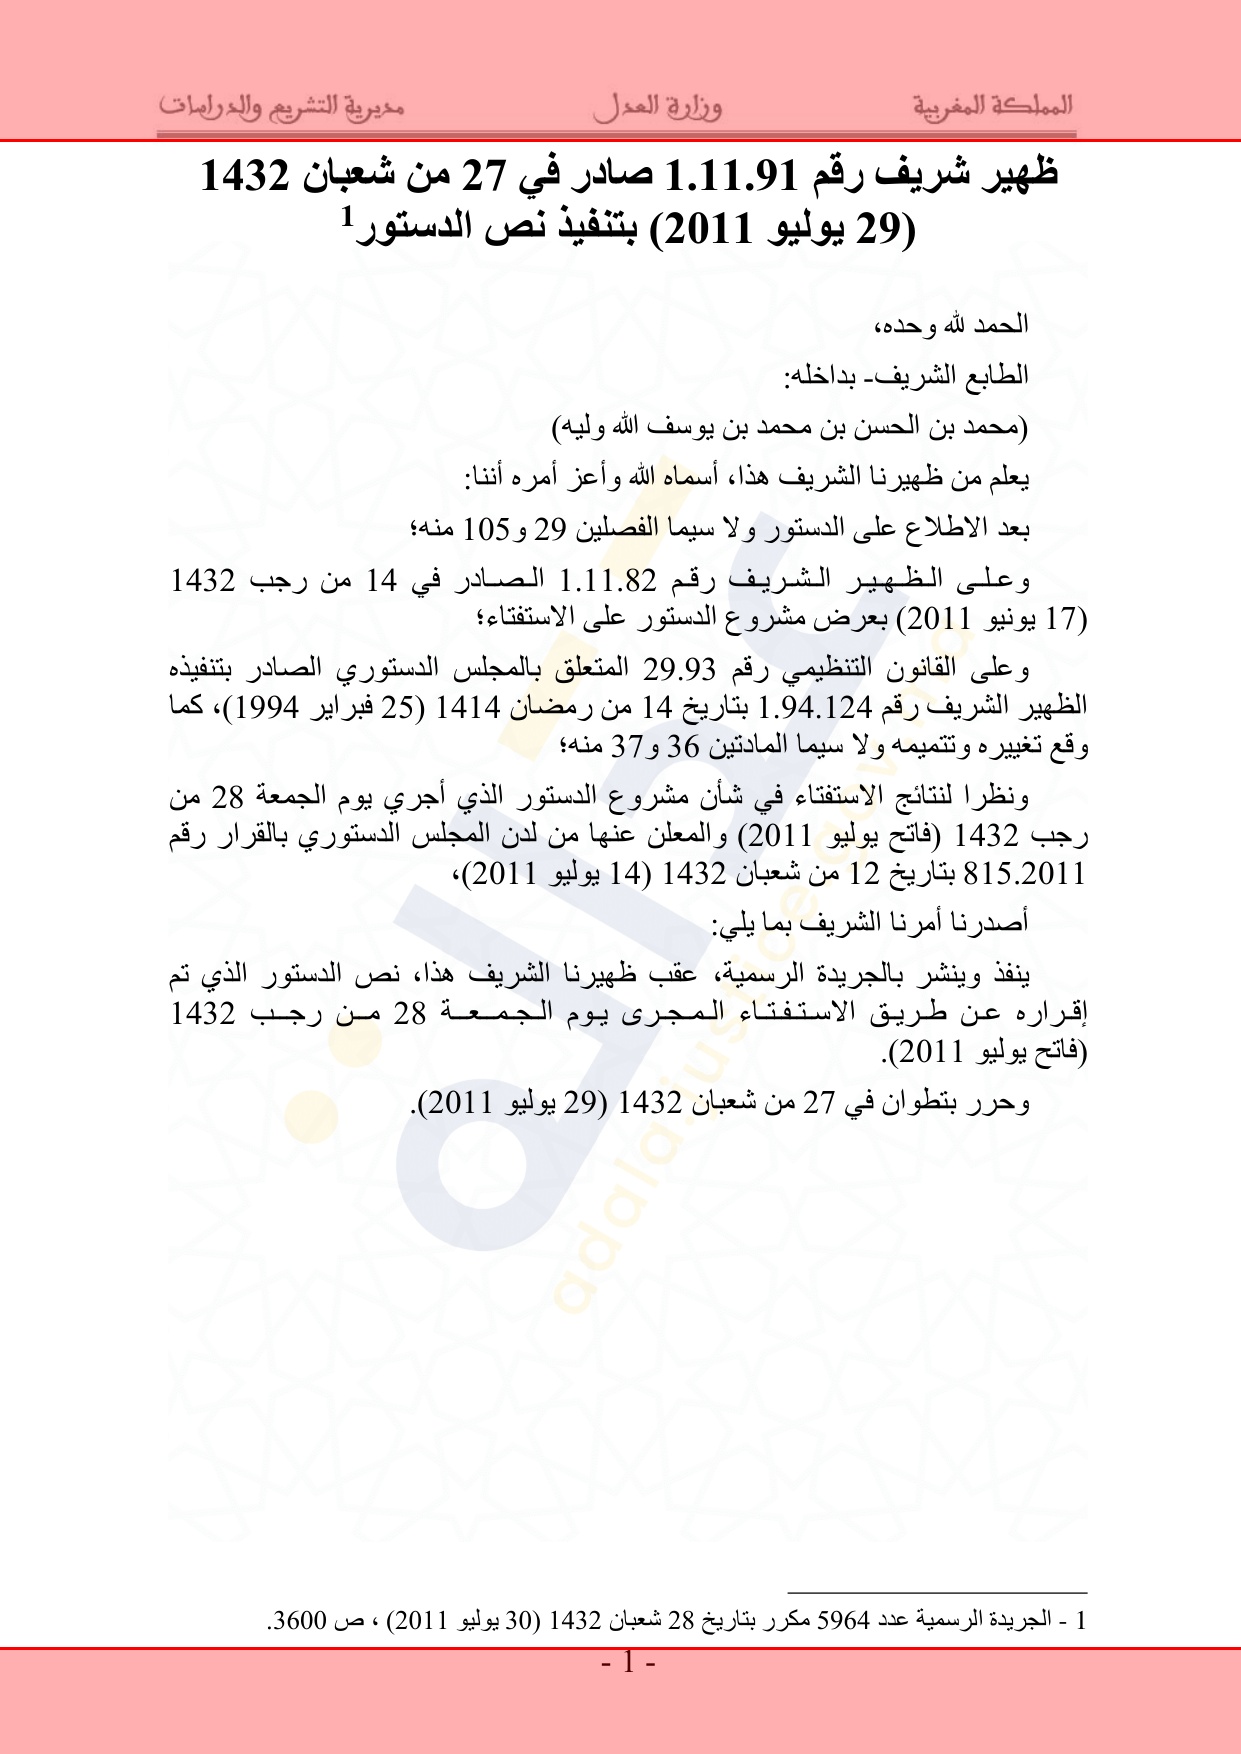

Page height: 842pt
Top crop:    8% = 67pt (red zone top)
Bottom crop: 6% = 51pt (red zone bottom)
Kept area:   67pt → 791pt (724pt)


In [11]:
# Visualize the crop area on the page
from IPython.display import display, Image as IPImage

doc = fitz.open("download/الدستور-1706626006826.pdf")
page = doc[1]

crop_top_pct = 8
crop_bottom_pct = 6

h = page.rect.height
top_y = page.rect.y0 + h * crop_top_pct / 100
bottom_y = page.rect.y1 - h * crop_bottom_pct / 100

# Render the page as an image
pix = page.get_pixmap(dpi=150)
img_w, img_h = pix.width, pix.height

# Scale from PDF points to pixel coordinates
scale = img_h / page.rect.height
top_px = int((top_y - page.rect.y0) * scale)
bottom_px = int((bottom_y - page.rect.y0) * scale)

# Draw red overlay on cropped regions
import io
from PIL import Image, ImageDraw

img = Image.frombytes("RGB", (img_w, img_h), pix.samples)
overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
draw = ImageDraw.Draw(overlay)

# Top crop zone — red semi-transparent
draw.rectangle([0, 0, img_w, top_px], fill=(255, 0, 0, 80))
# Bottom crop zone — red semi-transparent
draw.rectangle([0, bottom_px, img_w, img_h], fill=(255, 0, 0, 80))
# Crop boundary lines
draw.line([(0, top_px), (img_w, top_px)], fill=(255, 0, 0, 255), width=3)
draw.line([(0, bottom_px), (img_w, bottom_px)], fill=(255, 0, 0, 255), width=3)

result = Image.alpha_composite(img.convert("RGBA"), overlay)

buf = io.BytesIO()
result.save(buf, format="PNG")
display(IPImage(data=buf.getvalue()))

print(f"Page height: {h:.0f}pt")
print(f"Top crop:    {crop_top_pct}% = {top_y - page.rect.y0:.0f}pt (red zone top)")
print(
    f"Bottom crop: {crop_bottom_pct}% = {page.rect.y1 - bottom_y:.0f}pt (red zone bottom)"
)
print(f"Kept area:   {top_y:.0f}pt → {bottom_y:.0f}pt ({bottom_y - top_y:.0f}pt)")

doc.close()

In [13]:
doc = fitz.open("download/الدستور-1706626006826.pdf")
page = doc[1]

# Crop 8% top (header), 6% bottom (page number)
text = extract_page(
    page, crop_top=8, crop_bottom=6, detect_footer=False, crop_unit="pct"
)
print(text)

doc.close()

ظهير شريف رقم 1.11.91 صادر في 27 من شعبان 1432

(29 يوليو 2011) بتنفيذ نص الدستور 1

الحمد لله وحده،

الطابع الشريف- بداخله:

(محمد بن الحسن بن محمد بن يوسف الله وليه)

يعلم من ظهيرنا الشريف هذا، أسماه الله وأعز أمره أننا:

بعد الاطلاع على الدستور ولا سيما الفصلين 29 و 105 منه؛

وعلى الظهير الشريف رقم 1.11.82 الصادر في 14 من رجب 1432

(17 يونيو 2011) بعرض مشروع الدستور على الاستفتاء؛

وعلى القانون التنظيمي رقم 29.93 المتعلق بالمجلس الدستوري الصادر بتنفيذه

الظهير الشريف رقم 1.94.124 بتاريخ 14 من رمضان 1414 (25 فبراير 1994)، كما

وقع تغييره وتتميمه ولا سيما المادتين 36 و 37 منه؛

ونظرا لنتائج الاستفتاء في شأن مشروع الدستور الذي أجري يوم الجمعة 28 من

رجب 1432 (فاتح يوليو 2011) والمعلن عنها من لدن المجلس الدستوري بالقرار رقم

،)2011 ويلوي 14( 1432 نابعش نم 12 خيراتب 815.2011

أصدرنا أمرنا الشريف بما يلي:

ينفذ وينشر بالجريدة الرسمية، عقب ظهيرنا الشريف هذا، نص الدستور الذي تم

إقراره عن طريق الاستفتاء المجرى يوم الجمعة 28 من رجب 1432

(فاتح يوليو 2011).

وحرر بتطوان في 27 من شعبان 1432 (2

## 7. Batch processing: All PDFs in a directory


In [ ]:
import os

input_dir = "download"
output_dir = "output/plain_text"
os.makedirs(output_dir, exist_ok=True)

for filename in os.listdir(input_dir):
    if not filename.lower().endswith(".pdf"):
        continue
    pdf_path = os.path.join(input_dir, filename)
    text = extract_pdf(pdf_path, crop_top=50, crop_bottom=30)

    out_path = os.path.join(output_dir, filename.replace(".pdf", ".txt"))
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(text)
    print(f"✓ {filename} → {len(text):,} chars")

## 8. Integration example: Use in another project

```python
# In your law_infra project:
from pdfarabic import extract_pdf

def extract_law_text(path: str) -> str:
    return extract_pdf(
        path,
        crop_top=50,       # remove header
        crop_bottom=30,    # remove page numbers
        detect_footer=True # auto-remove footnotes
    )

# Then pass to your article splitter
text = extract_law_text("path/to/law.pdf")
articles, status = split_into_articles(text)
```
